In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import os, sys

def get_dir_n_levels_up(path, n):
    # Go up n levels from the given path
    for _ in range(n):
        path = os.path.dirname(path)
    return path


proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 4)
sys.path.append(proj_root)

print(proj_root)

d:\Work\repos\RL\phd-rl-algos


In [43]:
import numpy as np
from rl_envs_forge.envs.network_graph.network_graph import NetworkGraph

from dqn.opinion_dynamics.utils.env_setup import EnvironmentFactory

from dynamic_programming.opinion_dynamics.algos import compute_average_error, compute_final_average_error, generate_full_control_policy, generate_control_from_vector
from dynamic_programming.opinion_dynamics.algo_infinite_horizon import value_iteration, extract_policy, create_state_grid
from dynamic_programming.opinion_dynamics.common.viz import plot_opinions_over_time, visualize_policy_from_env


In [44]:
import contextlib
import matplotlib.pyplot as plt

@contextlib.contextmanager
def intercept_show(pre_show=None):
    """
    Temporarily wraps plt.show() so you can modify the current figure/axes
    right before it is displayed.
    """
    original_show = plt.show

    def wrapped_show(*args, **kwargs):
        if pre_show is not None:
            pre_show()
        return original_show(*args, **kwargs)

    plt.show = wrapped_show
    try:
        yield
    finally:
        plt.show = original_show


def _apply_bw_style(grid: bool = False,  grid_axis: str = "y"):
    """
    Enforce: white background, black lines, optional grid removal.
    Tries to handle NetworkX drawings + Seaborn barplots.
    """
    fig = plt.gcf()
    ax = plt.gca()

    # Backgrounds
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # Grid
    ax.set_axisbelow(True)  # grid behind bars; set False if you want grid on top
    if grid:
        ax.grid(
            True,
            axis=grid_axis,     # "y" is usually what you want for bar plots
            which="major",
            color="black",
            alpha=0.25,
            linewidth=0.8,
            linestyle="-",
        )
    else:
        ax.grid(False)

    # Spines / ticks
    for spine in ax.spines.values():
        spine.set_color("black")
    ax.tick_params(colors="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")

    # Lines (if any)
    for line in ax.get_lines():
        line.set_color("black")

    # Bars / patches (seaborn barplot uses ax.patches)
    for p in ax.patches:
        # publication-style: white fill, black outline
        p.set_facecolor("white")
        p.set_edgecolor("black")
        p.set_linewidth(1.0)

    # Collections (NetworkX nodes are PathCollection; edges may be LineCollection)
    for c in ax.collections:
        # Try making edge-ish things black
        try:
            c.set_edgecolor("black")
        except Exception:
            pass
        try:
            c.set_color("black")
        except Exception:
            pass
        # If it's a node collection, make them white with black outline
        try:
            fc = c.get_facecolor()
            if fc is not None and len(fc) > 0:
                c.set_facecolor("white")
        except Exception:
            pass

    # Arrow patches (NetworkX directed edges)
    for p in ax.patches:
        try:
            # FancyArrowPatch responds to set_edgecolor / set_facecolor sometimes
            p.set_edgecolor("black")
            p.set_facecolor("black")
        except Exception:
            pass


def render_styled(env, mode="centralities", *, theme="bw", grid=False, **render_kwargs):
    """
    Wrap env.render() without modifying the package.
    theme:
      - "bw": force white background + black strokes (and grid toggle)
      - "default": do nothing
    grid:
      - True/False
    render_kwargs:
      - forwarded to env.render(...) if it accepts them (harmless if ignored)
    """
    if theme == "bw":
        with intercept_show(pre_show=lambda: _apply_bw_style(grid=grid)):
            return env.render(mode=mode, **render_kwargs)
    else:
        return env.render(mode=mode, **render_kwargs)

c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\rl_envs_forge\envs\network_graph\visualize.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_labels, y=sorted_centralities, palette="Blues_d")


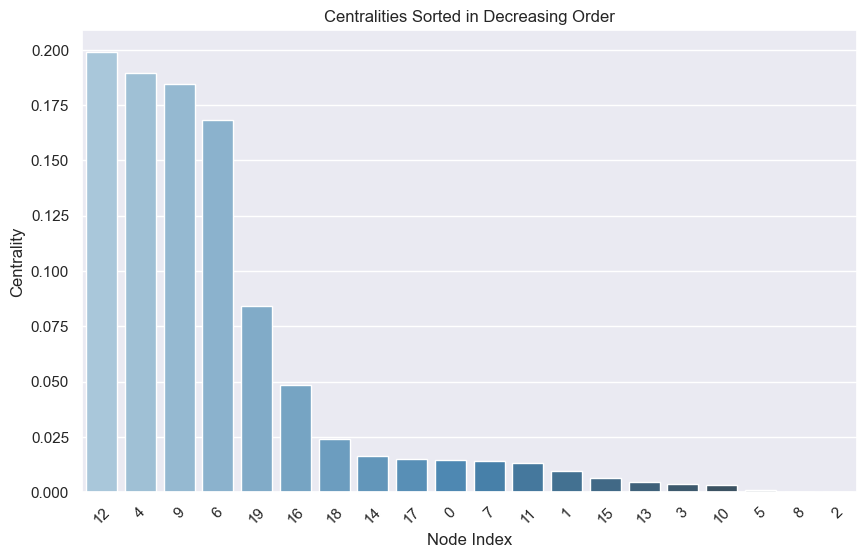

In [45]:
env_factory = EnvironmentFactory()
env = env_factory.get_randomized_env()
env.render(mode="centralities")

c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\rl_envs_forge\envs\network_graph\visualize.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_labels, y=sorted_centralities, palette="Blues_d")


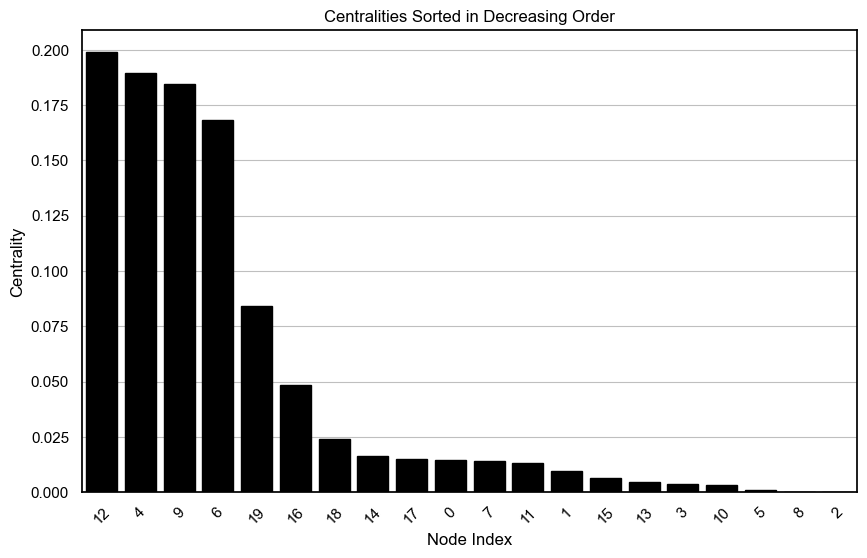

In [46]:
render_styled(env, mode="centralities", theme="bw", grid=True)

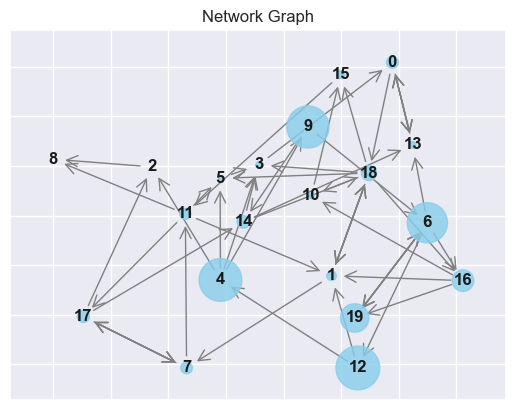

In [47]:
env.render(mode="matplotlib")

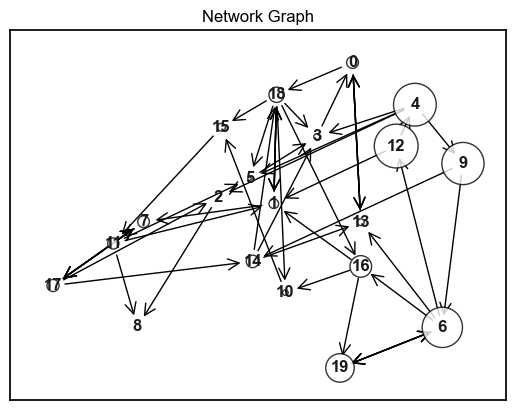

In [59]:
render_styled(env, mode="matplotlib", theme="bw", grid=False)

In [51]:
env.centralities

array([0.01453041, 0.00958603, 0.        , 0.0036326 , 0.18934941,
       0.00121087, 0.16815923, 0.01412679, 0.        , 0.18450594,
       0.00325421, 0.01301683, 0.19893545, 0.00484347, 0.01634671,
       0.00650841, 0.04845993, 0.01523675, 0.02421735, 0.08407961])